# PyIBS Example 3: Posterior and model evidence with PyVBMC

This notebook uses IBS estimates of a log-likelihood with PyVBMC to infer a posterior over model parameters and estimate the model evidence. We then compare the result with numerical integration of the closed-form likelihood.

It is the third example in this series, using the orientation discrimination model and data set from the [first notebook](./pyibs_example_1_basic_usage.ipynb). The [second](./pyibs_example_2_maximum_likelihood_with_pybads.ipynb) fits the model by maximum likelihood. The code is also available as a [Python script](https://github.com/acerbilab/pyibs/blob/main/examples/scripts/pyibs_example_3_posterior_with_pyvbmc.py).

See the [installation guide](https://acerbilab.github.io/pyibs/installation.html) for PyIBS and the packages needed to run this notebook.

In [1]:
import math

import numpy as np
from pyvbmc import VBMC
from pyvbmc.priors import Trapezoidal
from scipy.optimize import minimize
from scipy.special import logsumexp

from pyibs import IBS
from pyibs.examples.psycho_model import psycho_generator, psycho_neg_logl

## 0. Posterior and model evidence

Bayesian inference combines a likelihood and a prior to obtain the *posterior* distribution over parameters $\theta$ given data $\mathcal{D}$:

$$
p(\theta\mid\mathcal{D})=\frac{p(\mathcal{D}\mid\theta)\,p(\theta)}{p(\mathcal{D})}.
$$

The normalization constant

$$
p(\mathcal{D})=\int p(\mathcal{D}\mid\theta)\,p(\theta)\,d\theta
$$

is the *model evidence*, or marginal likelihood. It is used to compare models under their specified priors.

Variational Bayesian Monte Carlo (VBMC) uses a Gaussian process surrogate to approximate the posterior with a variational distribution while limiting costly target evaluations. It also estimates the ELBO, the evidence lower bound, which approaches the log evidence as the approximation improves. PyVBMC handles noisy log-likelihood evaluations when each returns an estimated SD, so IBS can supply its target.

## 1. The model, data and prior

Our parameters are $\theta=(\eta,\mu,\gamma)$: log sensory-noise SD, response bias and lapse rate. We generate the same 600 trials as in the other notebooks, with orientations drawn from a normal distribution of SD 3° and responses at $\theta_\text{true}=(\log 1,0.2,0.03)$.

The root seed supplies separate streams for data generation, IBS and PyVBMC. The data seed is shared with the other notebooks. Keeping the estimation streams separate makes the simulator draws independent of the generated data.

In [2]:
# Independent seeds for the data, the IBS estimates and PyVBMC
seed_data, seed_ibs, seed_vbmc = np.random.SeedSequence(2026).spawn(3)

theta_true = np.array([math.log(1.0), 0.2, 0.03])  # log(sigma), bias, lapse
n_trials = 600

rng = np.random.default_rng(seed_data)
S = 3 * rng.standard_normal((n_trials, 1))  # Orientation of each trial
R = psycho_generator(theta_true, S, rng)  # Response of each trial

The hard and plausible bounds describe the model's support and likely parameter range, using the values from the previous notebook. We place an independent trapezoidal prior on each parameter: its density is flat between the plausible bounds and decreases linearly to zero at the hard bounds. PyVBMC provides this joint prior as `Trapezoidal`.

The bounds, prior and data-generation recipe follow MATLAB IBS's `ibs_example.m`.

In [3]:
LB = np.array([math.log(0.1), -2.0, 0.01])  # Lower bounds
UB = np.array([math.log(10.0), 2.0, 1.0])  # Upper bounds
PLB = np.array([math.log(0.2), -1.0, 0.02])  # Plausible lower bounds
PUB = np.array([math.log(5.0), 1.0, 0.2])  # Plausible upper bounds

prior = Trapezoidal(LB, PLB, PUB, UB)

## 2. Supplying a noisy log-likelihood

With `prior=prior`, PyVBMC adds the log prior to each target evaluation. Our target therefore returns a log-likelihood estimate, using `return_positive=True`, together with its estimated SD, using `additional_output="std"`. The option `specify_target_noise=True` tells PyVBMC to read this pair.

The second value must be an SD, in the same units as the log-likelihood, and must be finite and positive. We use 100 repeats to obtain noise near 1 for this data set. PyVBMC works best around that level, and not much above 3, in the region carrying most posterior mass (see the [PyVBMC FAQ](https://acerbilab.org/pyvbmc/faq.html#faq-how-large-can-the-noise-be-to-perform-successful-inferences-with-vbmc)).

In [4]:
ibs = IBS(psycho_generator, R, S, vectorized=True, random_seed=seed_ibs)


def log_likelihood(theta):
    """IBS estimate of the log-likelihood, and its SD."""
    return ibs(
        theta, num_reps=100, additional_output="std", return_positive=True
    )

## 3. Running PyVBMC

We start at the center of the plausible box, as `ibs_example.m` does. The `seed` argument controls PyVBMC's random stream; the `IBS` object's seed controls the simulator draws. PyVBMC's results are reproducible on the same machine and numerical setup.

PyVBMC takes the starting point and the bounds as arrays of shape `(1, D)`, and reports when it reshapes the 1-D arrays supplied here; it calls the target with a 1-D parameter vector. `optimize()` runs inference and prints one progress line per iteration.

In [5]:
x0 = (PLB + PUB) / 2
vbmc = VBMC(
    log_likelihood,
    x0,
    LB,
    UB,
    PLB,
    PUB,
    options={"specify_target_noise": True},
    prior=prior,
    seed=seed_vbmc,
)
vp, results = vbmc.optimize()

Reshaping x0 to row vector.
Reshaping lower bounds to (1, 3).
Reshaping upper bounds to (1, 3).
Reshaping plausible lower bounds to (1, 3).
Reshaping plausible upper bounds to (1, 3).
Beginning variational optimization assuming NOISY observations of the log-joint
PyVBMC is using standard performance settings. You can optionally tune these for your machine by running pyvbmc.calibrate(). Calibration takes tens of seconds and does not evaluate your model.
Performance settings: standard settings.
 Iteration  f-count    Mean[ELBO]    Std[ELBO]    sKL-iter[q]   K[q]  Convergence  Action
     0         10        -166.64         3.24     14457.45        2        inf     start warm-up
     1         15        -163.46         0.67         5.02        2        inf     
     2         20        -162.00         0.44         0.34        2       8.53     
     3         25        -162.20         0.33         0.08        2       2.09     
     4         30        -161.00         0.37         1.83     

## 4. Inspecting the posterior

`vp` is the fitted variational posterior; `results` contains the estimated ELBO, its reported SD and information about the run. `vp.moments(cov_flag=True)` returns the mean and covariance of the variational posterior, from which we obtain marginal SDs.

In [6]:
post_mean, post_cov = vp.moments(cov_flag=True)
post_mean = post_mean.ravel()
post_sd = np.sqrt(np.diag(post_cov))
elbo, elbo_sd = results["elbo"], results["elbo_sd"]

print(f"ELBO: {elbo:.2f} +/- {elbo_sd:.2f}")
print(f"Target evaluations: {results['func_count']}")
print()
print(f"{'':16}{'eta':>8}{'bias':>8}{'lapse':>8}")
for name, values in [("Posterior mean", post_mean), ("Posterior SD", post_sd)]:
    print(f"{name:16}" + "".join(f"{x:8.4f}" for x in values))

ELBO: -160.18 +/- 0.13
Target evaluations: 130

                     eta    bias   lapse
Posterior mean    0.0356  0.2808  0.0293
Posterior SD      0.1004  0.0985  0.0121


`vp.plot()` displays the one- and two-dimensional marginals. As an orientation point, we mark the maximum-likelihood reference fit obtained by minimizing the closed-form negative log-likelihood. A posterior describes parameter uncertainty and includes the prior, so its mean need not coincide with that point.

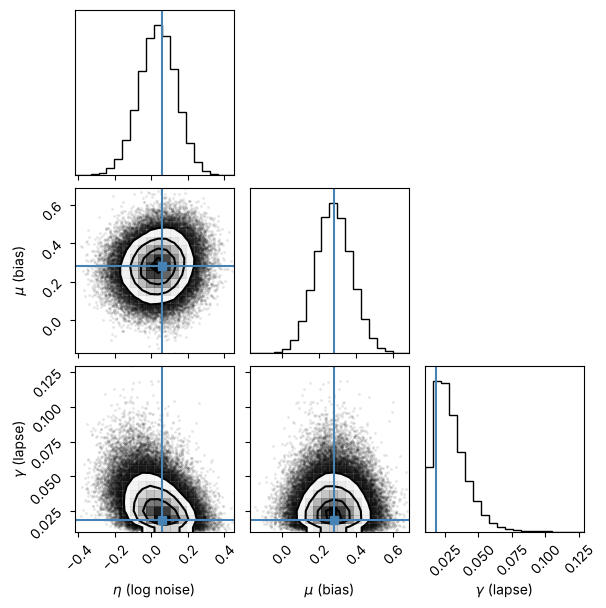

In [7]:
exact_fit = minimize(
    psycho_neg_logl,
    (PLB + PUB) / 2,
    args=(S, R),
    method="L-BFGS-B",
    bounds=list(zip(LB, UB)),
)
theta_ml = exact_fit.x

vp.plot(
    plot_style={
        "corner": {
            "labels": [
                r"$\eta$ (log noise)",
                r"$\mu$ (bias)",
                r"$\gamma$ (lapse)",
            ],
            "truths": theta_ml,
        }
    }
);

## 5. Building a numerical reference

This three-parameter model has a cheap closed-form likelihood, so we can integrate it on a grid to obtain a numerical reference for the log evidence and posterior moments. The grid evaluates the likelihood times the normalized prior; summing it with the grid-cell volume approximates the evidence. Normalized grid weights give posterior means and SDs.

We check both resolution and integration region. The first grid has 31 points per parameter in a box extending eight inferred posterior SDs either side of the posterior mean, clipped to the hard bounds. We refine it to 61 points, then widen the box to twelve SDs. The reported reference uses the refined eight-SD grid.

We require the log evidence to change by less than 0.02, the means by less than 0.02 posterior SDs, and the SDs by less than 0.5%. These checks assess discretization and omitted mass for this example; they do not make the integral exact. A grid becomes costly as the number of parameters grows.

In [8]:
def grid_reference(n_grid, width):
    """Numerical log evidence and posterior moments on a bounded grid."""
    axes = [
        np.linspace(max(lb, m - width * s), min(ub, m + width * s), n_grid)
        for lb, ub, m, s in zip(LB, UB, post_mean, post_sd)
    ]
    grid = np.stack(np.meshgrid(*axes, indexing="ij"), axis=-1).reshape(-1, 3)

    # Closed-form log likelihood plus the normalized log prior
    log_joint = prior.log_pdf(grid).ravel() - np.array(
        [psycho_neg_logl(theta, S, R) for theta in grid]
    )
    cell_volume = np.prod([a[1] - a[0] for a in axes])
    log_sum = logsumexp(log_joint)
    log_evidence = log_sum + math.log(cell_volume)
    weights = np.exp(log_joint - log_sum)
    mean = weights @ grid
    sd = np.sqrt(weights @ (grid - mean) ** 2)
    return log_evidence, mean, sd


configurations = [(31, 8), (61, 8), (61, 12)]
references = [grid_reference(n, width) for n, width in configurations]
log_evidence, reference_mean, reference_sd = references[1]

print("Grid check: points per parameter, half-width in posterior SDs, log Z")
for (n, width), (log_z, mean, sd) in zip(configurations, references):
    delta_log_z = abs(log_z - log_evidence)
    delta_mean = np.max(abs(mean - reference_mean) / reference_sd)
    delta_sd = np.max(abs(sd - reference_sd) / reference_sd)
    print(
        f"{n:3d} points, {width} SDs: {log_z:.5f}; "
        f"changes {delta_log_z:.4f} in log Z, "
        f"{delta_mean:.4f} SDs in mean, {delta_sd:.2%} in SD"
    )
    assert delta_log_z < 0.02, "Refine or widen the evidence grid."
    assert delta_mean < 0.02, "Refine or widen the posterior grid."
    assert delta_sd < 0.005, "Refine or widen the posterior grid."

print()
print(f"ELBO (PyVBMC):          {elbo:.2f} +/- {elbo_sd:.2f}")
print(f"Numerical log evidence: {log_evidence:.2f}")
print()
print(f"{'':22}{'eta':>8}{'bias':>8}{'lapse':>8}")
for name, values in [
    ("Reference ML point", theta_ml),
    ("PyVBMC mean", post_mean),
    ("Grid mean", reference_mean),
    ("PyVBMC SD", post_sd),
    ("Grid SD", reference_sd),
]:
    print(f"{name:22}" + "".join(f"{x:8.4f}" for x in values))

Grid check: points per parameter, half-width in posterior SDs, log Z
 31 points, 8 SDs: -160.30179; changes 0.0056 in log Z, 0.0072 SDs in mean, 0.22% in SD
 61 points, 8 SDs: -160.29620; changes 0.0000 in log Z, 0.0000 SDs in mean, 0.00% in SD
 61 points, 12 SDs: -160.29840; changes 0.0022 in log Z, 0.0028 SDs in mean, 0.05% in SD

ELBO (PyVBMC):          -160.18 +/- 0.13
Numerical log evidence: -160.30

                           eta    bias   lapse
Reference ML point      0.0584  0.2828  0.0184
PyVBMC mean             0.0356  0.2808  0.0293
Grid mean               0.0337  0.2836  0.0307
PyVBMC SD               0.1004  0.0985  0.0121
Grid SD                 0.1006  0.0984  0.0127


The ELBO is close to the numerical log evidence relative to its reported uncertainty, and the posterior means and SDs are close to the grid reference. The grid's resolution and region checks change the reference much less than these differences.

The mathematical ELBO is bounded above by the log evidence and equals it when the variational distribution matches the posterior. PyVBMC estimates the ELBO from a noisy target and a surrogate model, so the *estimated* value can lie above the reference. Its reported `elbo_sd` describes uncertainty in that estimate; the quality of the posterior approximation also matters when interpreting evidence. For model comparison, assess the uncertainty relative to the differences between models, and compare repeated runs when those differences are small.

In this run, the posterior mean is within one posterior SD of the maximum-likelihood reference point in each parameter. The lapse-rate marginal is skewed: its lower bound is 0.01, where the prior vanishes, and its longer tail toward larger lapse rates pulls the mean above the maximum-likelihood estimate. The marginal plots make this difference visible.

## 6. Applying the workflow to another model

An IBS target needs a simulator, observed responses and trial conditions. Returning its log-likelihood estimate and estimated SD lets PyVBMC combine it with a prior to approximate the posterior and model evidence. The closed-form likelihood in this example makes an independent numerical check possible. For a model without that reference, use PyVBMC's convergence diagnostics, inspect the posterior and compare independent runs.

## References

1. van Opheusden, B., Acerbi, L. & Ma, W. J. (2020). Unbiased and efficient log-likelihood estimation with inverse binomial sampling. *PLOS Computational Biology* 16(12): e1008483. [https://doi.org/10.1371/journal.pcbi.1008483](https://doi.org/10.1371/journal.pcbi.1008483)
2. Huggins, B., Li, C., Tobaben, M., Aarnos, M. & Acerbi, L. (2023). PyVBMC: Efficient Bayesian inference in Python. *Journal of Open Source Software* 8(86): 5428. [https://doi.org/10.21105/joss.05428](https://doi.org/10.21105/joss.05428)
3. Acerbi, L. (2018). Variational Bayesian Monte Carlo. In *Advances in Neural Information Processing Systems 31*: 8222-8232. [https://arxiv.org/abs/1810.05558](https://arxiv.org/abs/1810.05558)
4. Acerbi, L. (2020). Variational Bayesian Monte Carlo with noisy likelihoods. In *Advances in Neural Information Processing Systems 33*: 8211-8222. [https://arxiv.org/abs/2006.08655](https://arxiv.org/abs/2006.08655)